# Experiment: Inspect Trust-me MOMENT Embeddings

This notebook evaluates what information is preserved in precomputed embeddings from `segment_trustme.py`.

Focus fields in this run:
- `sleep_feedback`
- `prompt_id`
- `prompt_time`
- survey columns `1` ... `9`


In [7]:
from pathlib import Path
import json
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True


In [8]:
# ---- Paths and knobs ----
CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
ROOT = None
for cand in CANDIDATE_ROOTS:
    if (cand / 'trustME_trustme').exists():
        ROOT = cand.resolve()
        break
if ROOT is None:
    ROOT = Path.cwd().resolve()

EMB_DIR = ROOT / 'trustME_trustme/data/processed/trustme_tobii_0shot'
EMB_PATH = EMB_DIR / 'moment_embeddings.npz'
META_PATH = EMB_DIR / 'segments_metadata.parquet'
MANIFEST_PATH = EMB_DIR / 'manifest.json'

MAX_ROWS_FOR_ANALYSIS = 100_000   # None -> use all rows
PCA_SUBSET_SIZE = 8_000
RANDOM_SEED = 42

MIN_ROWS_FOR_FIELD = 500
MIN_CLASS_COUNT = 40
CV_FOLDS = 5

TARGET_COLUMNS = ['sleep_feedback', 'prompt_id', 'prompt_time'] + [str(i) for i in range(1, 10)]

ROOT, EMB_DIR, EMB_PATH.exists(), META_PATH.exists(), MANIFEST_PATH.exists()


(PosixPath('/home/ppg/eyetracking/moment4ET'),
 PosixPath('/home/ppg/eyetracking/moment4ET/trustME_trustme/data/processed/trustme_tobii_0shot'),
 True,
 True,
 True)

In [9]:
if MANIFEST_PATH.exists():
    manifest = json.loads(MANIFEST_PATH.read_text())
    print('Manifest counts:', manifest.get('counts', {}))
    print('Model:', manifest.get('model', {}))
else:
    manifest = {}
    print('manifest.json not found.')

if META_PATH.exists():
    metadata = pd.read_parquet(META_PATH)
    print('Metadata shape:', metadata.shape)
else:
    metadata = pd.DataFrame()
    print('segments_metadata.parquet not found.')

if not EMB_PATH.exists():
    raise FileNotFoundError(f'Missing embeddings file: {EMB_PATH}')

payload = np.load(EMB_PATH, allow_pickle=False)
embeddings = payload['embeddings'].astype(np.float32)
segment_ids = payload['segment_id'].astype(str)

print('Embeddings shape:', embeddings.shape)
print('Segment IDs shape:', segment_ids.shape)
print('Embedding file size (MB):', round(EMB_PATH.stat().st_size / (1024 * 1024), 1))

if metadata.empty:
    aligned_meta = pd.DataFrame({'segment_id': segment_ids})
else:
    if 'segment_id' not in metadata.columns:
        raise ValueError('Metadata missing required `segment_id` column.')

    meta_idx = metadata.copy()
    meta_idx['segment_id'] = meta_idx['segment_id'].astype(str)
    meta_idx = meta_idx.set_index('segment_id', drop=False)

    missing = sorted(set(segment_ids) - set(meta_idx.index))
    if missing:
        raise ValueError(f'Missing metadata rows for {len(missing)} segment_ids. First few: {missing[:5]}')

    aligned_meta = meta_idx.loc[segment_ids].reset_index(drop=True)

print('Aligned metadata shape:', aligned_meta.shape)


Manifest counts: {'drop_reason_counts': {'low_valid_fraction': 425213, 'too_few_valid_frames': 4}, 'metadata_rows': 118252, 'parquet_files_processed': 65, 'segments_dropped': 425217, 'segments_kept': 118252, 'segments_total_candidates': 543469, 'subjects_processed': 2}
Model: {'batch_size': 64, 'computed_embeddings': False, 'device': 'auto', 'name': 'AutonLab/MOMENT-1-large', 'reduction': 'mean', 'reused_inputs': True, 'task_name': 'embedding'}
Metadata shape: (118252, 29)
Embeddings shape: (118252, 1024)
Segment IDs shape: (118252,)
Embedding file size (MB): 428.3
Aligned metadata shape: (118252, 29)


In [10]:
# Optional row subsample for faster interactive analysis
n_total = embeddings.shape[0]
if MAX_ROWS_FOR_ANALYSIS is None or MAX_ROWS_FOR_ANALYSIS >= n_total:
    idx = np.arange(n_total)
else:
    rng = np.random.default_rng(RANDOM_SEED)
    idx = np.sort(rng.choice(n_total, size=MAX_ROWS_FOR_ANALYSIS, replace=False))

X = embeddings[idx]
meta_sub = aligned_meta.iloc[idx].reset_index(drop=True)

print(f'Using {len(idx):,}/{n_total:,} rows for analysis')
print('Embedding dim:', X.shape[1])

norms = np.linalg.norm(X, axis=1)
print('Norms min/mean/max:', round(float(norms.min()), 3), round(float(norms.mean()), 3), round(float(norms.max()), 3))

if 'prompt_time' in meta_sub.columns:
    meta_sub['prompt_time_dt'] = pd.to_datetime(meta_sub['prompt_time'], errors='coerce')
    t0 = meta_sub['prompt_time_dt'].min()
    if pd.notna(t0):
        meta_sub['prompt_time_hours_from_start'] = (
            (meta_sub['prompt_time_dt'] - t0).dt.total_seconds() / 3600.0
        )
    else:
        meta_sub['prompt_time_hours_from_start'] = np.nan

completeness = []
for c in TARGET_COLUMNS:
    if c not in meta_sub.columns:
        completeness.append((c, 0, 0.0, 0))
        continue
    s = meta_sub[c]
    non_null = int(s.notna().sum())
    completeness.append((c, non_null, non_null / len(meta_sub), int(s.nunique(dropna=True))))

comp_df = pd.DataFrame(completeness, columns=['column', 'non_null_rows', 'non_null_fraction', 'unique_values'])
print(comp_df.sort_values('non_null_fraction', ascending=False).to_string(index=False))


Using 100,000/118,252 rows for analysis
Embedding dim: 1024
Norms min/mean/max: 2.48 2.67 2.828
        column  non_null_rows  non_null_fraction  unique_values
sleep_feedback          90815            0.90815              4
     prompt_id          11731            0.11731             76
   prompt_time          11731            0.11731             91
             3          11117            0.11117              7
             9           8992            0.08992              6
             1           8985            0.08985              4
             4           8972            0.08972              7
             2           8943            0.08943              6
             5           8908            0.08908              6
             6           8801            0.08801              5
             8           8498            0.08498              6
             7           7294            0.07294              4


In [11]:
def _subsample_for_plot(X_in: np.ndarray, meta_in: pd.DataFrame, n_rows: int, seed: int) -> tuple[np.ndarray, pd.DataFrame]:
    """Return deterministic random subset for visualization."""
    if X_in.shape[0] <= n_rows:
        return X_in, meta_in.reset_index(drop=True)

    rng = np.random.default_rng(seed)
    pick = np.sort(rng.choice(X_in.shape[0], size=n_rows, replace=False))
    return X_in[pick], meta_in.iloc[pick].reset_index(drop=True)


def _fit_pca_projection(X_in: np.ndarray, seed: int) -> tuple[np.ndarray, np.ndarray]:
    """Standardize embeddings and return 2D PCA projection and explained variance ratio."""
    X_std = StandardScaler().fit_transform(X_in)
    pca = PCA(n_components=2, random_state=seed)
    Z = pca.fit_transform(X_std)
    return Z, pca.explained_variance_ratio_


def plot_pca_by_categorical(
    Z: np.ndarray,
    series: pd.Series,
    title: str,
    max_levels: int = 10,
    dropna: bool = True,
    dropother: bool = True,
) -> None:
    """Scatter PCA projection colored by categorical metadata values."""
    labels = series.astype('string')

    # Keep only top levels; collapse the rest as "other".
    top_levels = labels.dropna().value_counts().index[:max_levels]
    labels_plot = labels.where(labels.isin(top_levels), other='other')

    # Optionally hide NaN and/or "other" points.
    if dropna:
        labels_plot = labels_plot.where(labels.notna(), other=pd.NA)
    if dropother:
        labels_plot = labels_plot.where(labels_plot != 'other', other=pd.NA)

    valid_levels = sorted(labels_plot.dropna().astype(str).unique().tolist())
    if len(valid_levels) == 0:
        print(f'Skipping {title}: no points remain after filtering.')
        return

    labels_str = labels_plot.astype('string')

    fig, ax = plt.subplots(figsize=(8, 6))
    for level in valid_levels:
        mask = labels_str.eq(level).fillna(False).to_numpy()
        ax.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.55, label=level)

    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left', title='value')
    plt.tight_layout()
    plt.show()


def plot_pca_by_continuous(Z: np.ndarray, values: pd.Series, title: str, color_label: str) -> None:
    """Scatter PCA projection colored by continuous metadata values."""
    mask = values.notna().to_numpy()
    if mask.sum() < 2:
        print(f'Skipping {title}: not enough non-null values.')
        return

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(Z[mask, 0], Z[mask, 1], c=values[mask], cmap='viridis', s=8, alpha=0.65)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(color_label)
    plt.tight_layout()
    plt.show()


def evaluate_categorical_signal(
    X_in: np.ndarray,
    series: pd.Series,
    column_name: str,
    min_rows: int,
    min_class_count: int,
    cv_folds: int,
    seed: int,
) -> Optional[dict]:
    """Estimate metadata recoverability via balanced-accuracy logistic regression CV."""
    mask = series.notna()
    if int(mask.sum()) < min_rows:
        return None

    y = series[mask].astype('string')
    Xv = X_in[mask.to_numpy()]

    counts = y.value_counts()
    kept_levels = counts[counts >= min_class_count].index
    keep_mask = y.isin(kept_levels)

    y = y[keep_mask]
    Xv = Xv[keep_mask.to_numpy()]
    if y.nunique() < 2 or len(y) < min_rows:
        return None

    min_count = int(y.value_counts().min())
    n_splits = min(cv_folds, min_count)
    if n_splits < 2:
        return None

    y_codes = pd.Categorical(y).codes
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=seed),
    )

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = cross_val_score(pipe, Xv, y_codes, scoring='balanced_accuracy', cv=cv, n_jobs=-1)

    return {
        'column': column_name,
        'type': 'categorical',
        'rows_used': int(len(y_codes)),
        'n_classes': int(y.nunique()),
        'chance_level': float(1.0 / y.nunique()),
        'score_mean': float(np.mean(scores)),
        'score_std': float(np.std(scores)),
    }


def evaluate_continuous_signal(
    X_in: np.ndarray,
    series: pd.Series,
    column_name: str,
    min_rows: int,
    cv_folds: int,
    seed: int,
) -> Optional[dict]:
    """Estimate recoverability of continuous metadata with ridge-regression CV R2."""
    mask = series.notna()
    if int(mask.sum()) < min_rows:
        return None

    y = pd.to_numeric(series[mask], errors='coerce')
    valid = y.notna()
    y = y[valid].to_numpy(dtype=np.float32)
    Xv = X_in[mask.to_numpy()][valid.to_numpy()]

    if len(y) < min_rows:
        return None

    cv = KFold(n_splits=cv_folds, shuffle=True, random_state=seed)
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=seed))
    scores = cross_val_score(pipe, Xv, y, scoring='r2', cv=cv, n_jobs=-1)

    return {
        'column': column_name,
        'type': 'continuous',
        'rows_used': int(len(y)),
        'n_classes': np.nan,
        'chance_level': 0.0,
        'score_mean': float(np.mean(scores)),
        'score_std': float(np.std(scores)),
    }


PCA subset size: 8,000
Explained variance ratio (PC1, PC2): [0.1422 0.0747]


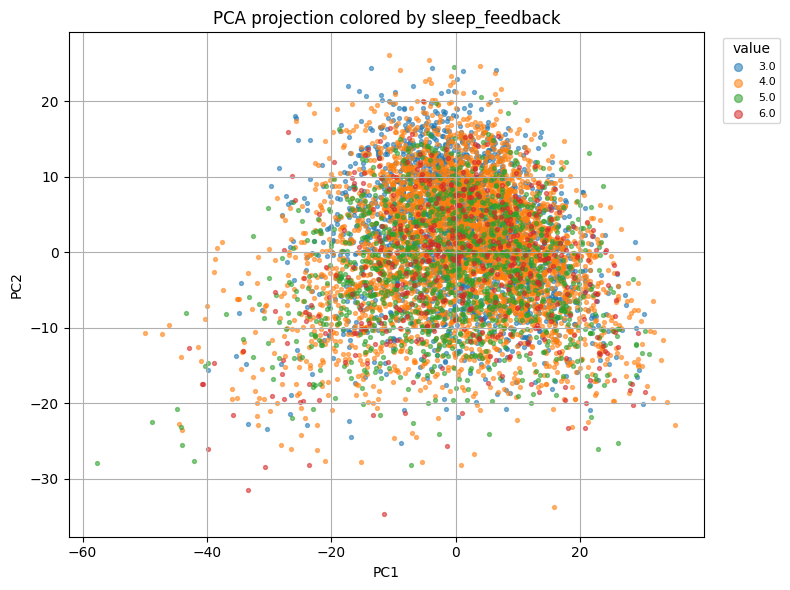

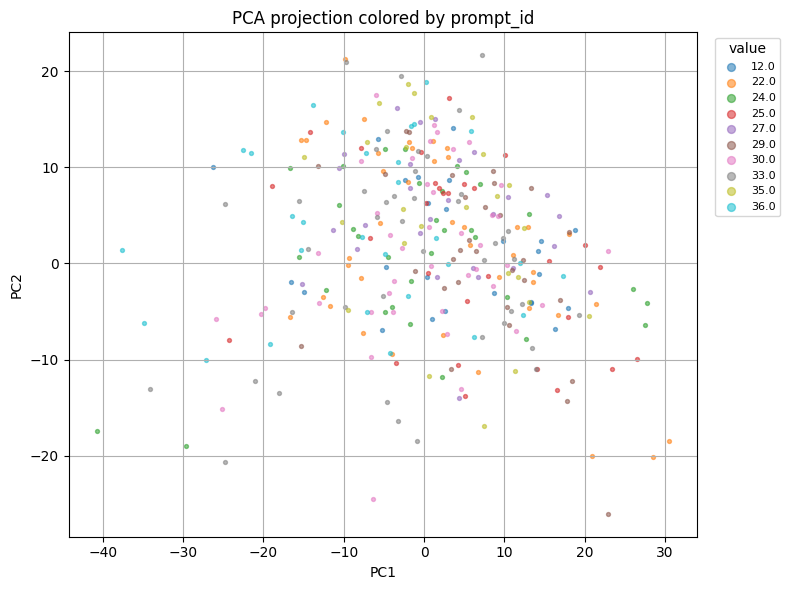

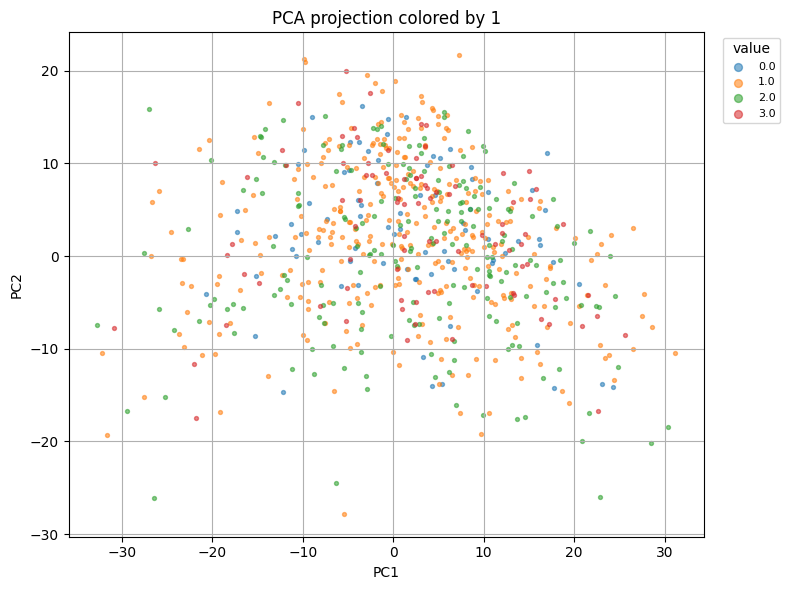

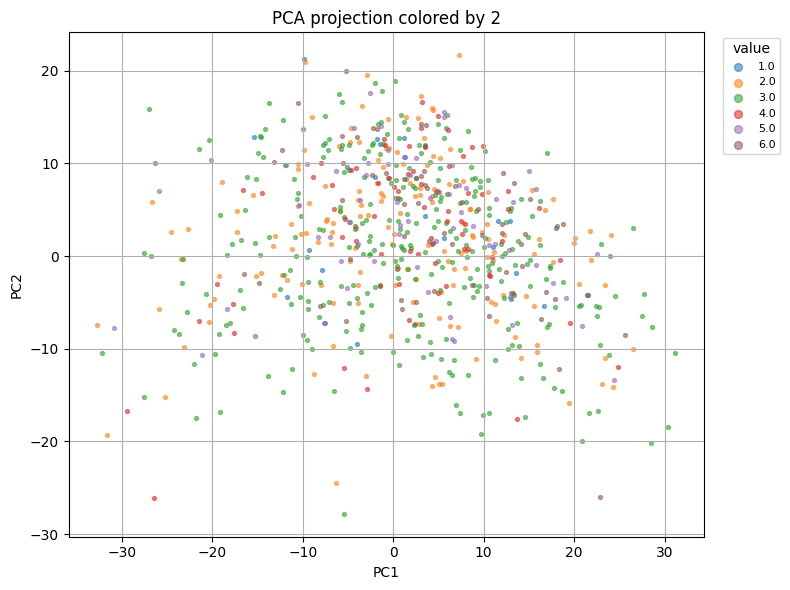

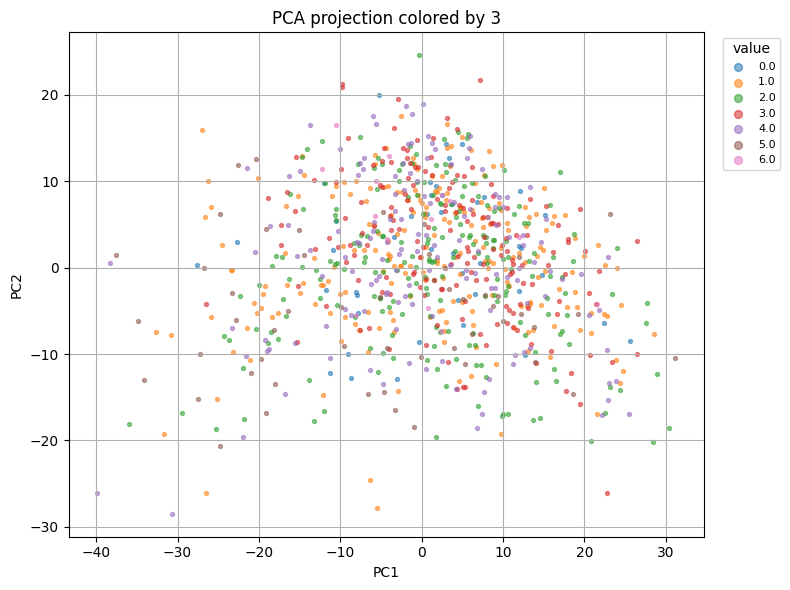

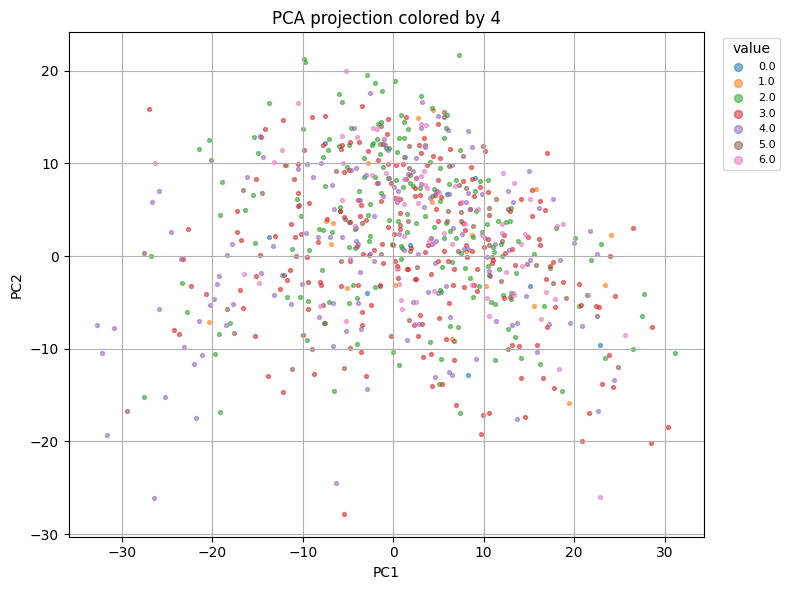

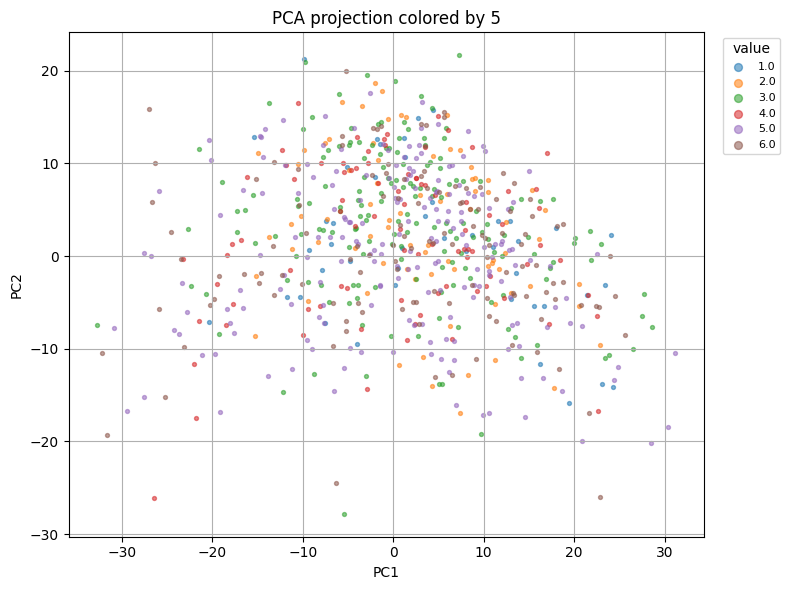

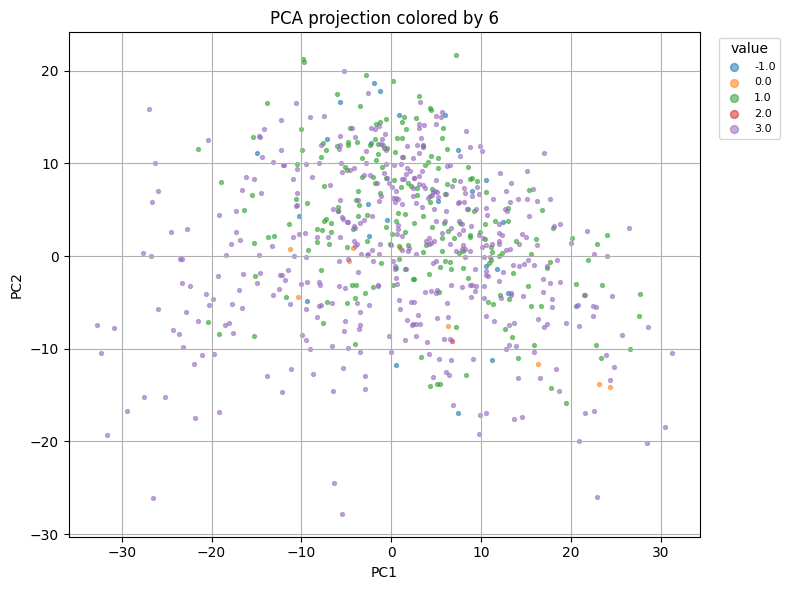

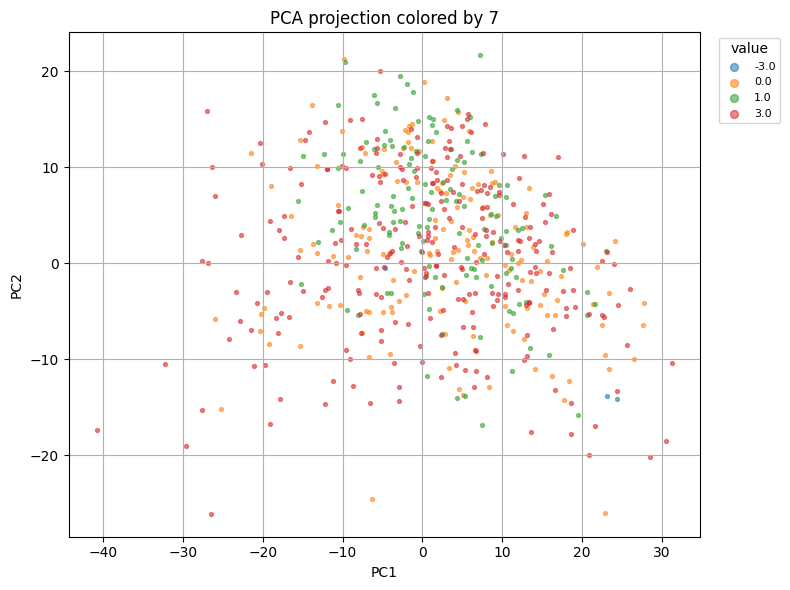

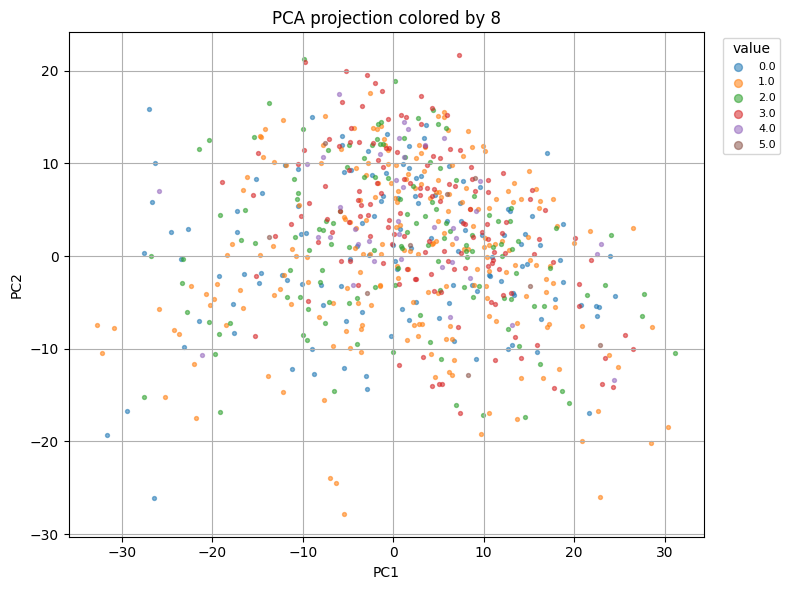

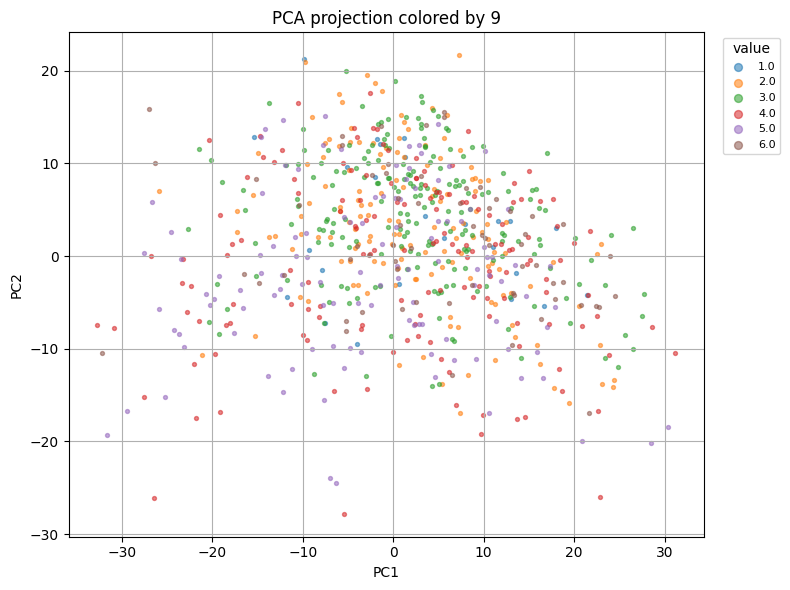

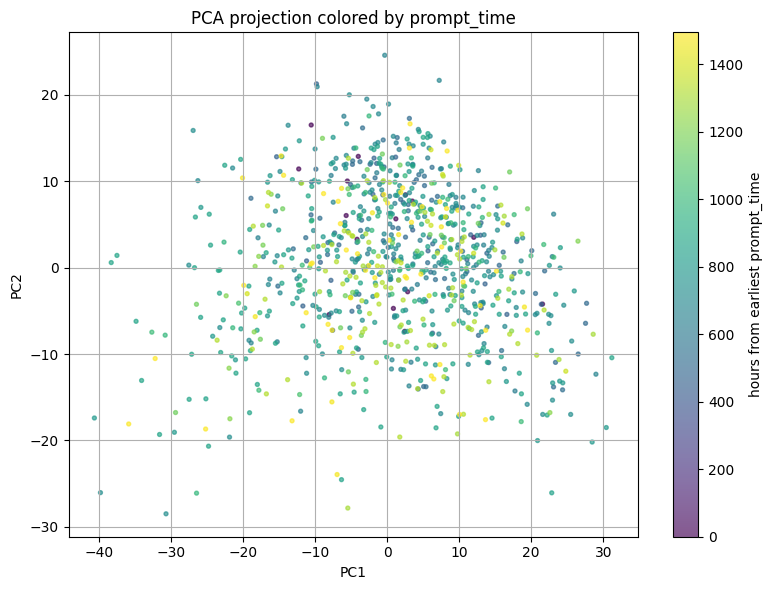

In [12]:
# ---- PCA visualizations ----
X_plot, meta_plot = _subsample_for_plot(X, meta_sub, n_rows=PCA_SUBSET_SIZE, seed=RANDOM_SEED)
Z, evr = _fit_pca_projection(X_plot, seed=RANDOM_SEED)

print(f'PCA subset size: {X_plot.shape[0]:,}')
print('Explained variance ratio (PC1, PC2):', np.round(evr, 4))

cat_plot_columns = ['sleep_feedback', 'prompt_id'] + [str(i) for i in range(1, 10)]
for col in cat_plot_columns:
    if col not in meta_plot.columns:
        print(f'Skipping {col}: column missing.')
        continue
    if meta_plot[col].notna().sum() < 50:
        print(f'Skipping {col}: too few non-null rows for plotting.')
        continue
    plot_pca_by_categorical(
        Z,
        meta_plot[col],
        title=f'PCA projection colored by {col}',
        max_levels=10,
    )

if 'prompt_time_hours_from_start' in meta_plot.columns:
    plot_pca_by_continuous(
        Z,
        meta_plot['prompt_time_hours_from_start'],
        title='PCA projection colored by prompt_time',
        color_label='hours from earliest prompt_time',
    )
else:
    print('Skipping prompt_time plot: parsed time column unavailable.')


In [13]:
# ---- Quantitative recoverability summary ----
results = []

for col in ['sleep_feedback', 'prompt_id'] + [str(i) for i in range(1, 10)]:
    if col in meta_sub.columns:
        out = evaluate_categorical_signal(
            X,
            meta_sub[col],
            column_name=col,
            min_rows=MIN_ROWS_FOR_FIELD,
            min_class_count=MIN_CLASS_COUNT,
            cv_folds=CV_FOLDS,
            seed=RANDOM_SEED,
        )
        if out is not None:
            results.append(out)

if 'prompt_time_hours_from_start' in meta_sub.columns:
    out = evaluate_continuous_signal(
        X,
        meta_sub['prompt_time_hours_from_start'],
        column_name='prompt_time',
        min_rows=MIN_ROWS_FOR_FIELD,
        cv_folds=CV_FOLDS,
        seed=RANDOM_SEED,
    )
    if out is not None:
        results.append(out)

results_df = pd.DataFrame(results)
if results_df.empty:
    print('No fields had enough valid data for quantitative evaluation.')
else:
    results_df = results_df.sort_values('score_mean', ascending=False).reset_index(drop=True)
    display_cols = ['column', 'type', 'rows_used', 'n_classes', 'chance_level', 'score_mean', 'score_std']
    print(results_df[display_cols].to_string(index=False, float_format=lambda x: f'{x:.4f}'))


        column        type  rows_used  n_classes  chance_level  score_mean  score_std
             7 categorical       7258     3.0000        0.3333      0.4523     0.0115
sleep_feedback categorical      90815     4.0000        0.2500      0.3756     0.0052
             6 categorical       8800     4.0000        0.2500      0.3512     0.0103
             1 categorical       8985     4.0000        0.2500      0.3208     0.0129
             9 categorical       8992     6.0000        0.1667      0.2653     0.0111
             8 categorical       8498     6.0000        0.1667      0.2487     0.0186
             2 categorical       8943     6.0000        0.1667      0.2356     0.0081
             5 categorical       8908     6.0000        0.1667      0.2285     0.0101
             4 categorical       8972     7.0000        0.1429      0.2184     0.0133
             3 categorical      11117     7.0000        0.1429      0.2143     0.0085
     prompt_id categorical      11439    56.0000      

In [14]:
# ---- Interpretation ----
if results_df.empty:
    print('Interpretation unavailable: no quantitative results were produced.')
else:
    cat_df = results_df[results_df['type'] == 'categorical'].copy()
    cont_df = results_df[results_df['type'] == 'continuous'].copy()

    print('Interpretation summary')
    print('======================')

    if not cat_df.empty:
        cat_df['gain_over_chance'] = cat_df['score_mean'] - cat_df['chance_level']
        top_cat = cat_df.sort_values('gain_over_chance', ascending=False).iloc[0]
        weak_cat = cat_df.sort_values('gain_over_chance', ascending=True).iloc[0]

        print(
            f"Strongest categorical signal: {top_cat['column']} "
            f"(balanced_acc={top_cat['score_mean']:.3f}, chance={top_cat['chance_level']:.3f}, "
            f"gain={top_cat['gain_over_chance']:.3f})."
        )
        print(
            f"Weakest categorical signal with enough coverage: {weak_cat['column']} "
            f"(balanced_acc={weak_cat['score_mean']:.3f}, chance={weak_cat['chance_level']:.3f}, "
            f"gain={weak_cat['gain_over_chance']:.3f})."
        )

        print('Categorical fields ranked by gain over chance:')
        print(
            cat_df.sort_values('gain_over_chance', ascending=False)[['column', 'score_mean', 'chance_level', 'gain_over_chance', 'rows_used']]
            .to_string(index=False, float_format=lambda x: f'{x:.3f}')
        )

    if not cont_df.empty:
        row = cont_df.iloc[0]
        print(
            f"Continuous signal (`{row['column']}`): R2={row['score_mean']:.3f} +/- {row['score_std']:.3f} "
            f"on {int(row['rows_used'])} rows."
        )
        if row['score_mean'] > 0.10:
            print('This suggests a meaningful temporal signature in embeddings.')
        elif row['score_mean'] > 0.02:
            print('This suggests a weak but non-trivial temporal signature in embeddings.')
        else:
            print('This suggests little recoverable linear temporal information.')

    print('')
    print('Caveats:')
    print('- Missingness is high for prompt-linked fields, so those results reflect a subset of sessions.')
    print('- Linear probes quantify recoverable signal, not causality.')
    print('- If needed, repeat with per-subject normalization to separate subject identity from prompt effects.')


Interpretation summary
Strongest categorical signal: sleep_feedback (balanced_acc=0.376, chance=0.250, gain=0.126).
Weakest categorical signal with enough coverage: prompt_id (balanced_acc=0.059, chance=0.018, gain=0.041).
Categorical fields ranked by gain over chance:
        column  score_mean  chance_level  gain_over_chance  rows_used
sleep_feedback       0.376         0.250             0.126      90815
             7       0.452         0.333             0.119       7258
             6       0.351         0.250             0.101       8800
             9       0.265         0.167             0.099       8992
             8       0.249         0.167             0.082       8498
             4       0.218         0.143             0.076       8972
             3       0.214         0.143             0.071      11117
             1       0.321         0.250             0.071       8985
             2       0.236         0.167             0.069       8943
             5       0.228    

## Notes
- Quantitative scores are probe-based diagnostics of what metadata is recoverable from embeddings.
- High score on a field means embeddings encode information correlated with that field, not necessarily only that field.
- Re-run with different `RANDOM_SEED` and/or stricter balancing to test robustness.
